# Sentiment Analysis of Amazon App Reviews

**Phase 3** of the pipeline: Build and compare ML classifiers on cleaned Amazon app reviews.

## Methodology
1. **Load** cleaned data from Phase 2 (`reviews_clean_for_sentiment.csv`) — fake reviews already removed
2. **Label** — Binary sentiment: Negative (1-2 stars) vs Positive (4-5 stars), exclude neutral 3-star
3. **Vectorize** — TF-IDF with unigrams + bigrams (10K features)
4. **Train & Evaluate** — 2 models: Logistic Regression, Multinomial Naive Bayes
5. **Visualize** — Confusion matrices, ROC curves, word clouds, feature importance
6. **Impact Analysis** — Compare filtered (clean) vs unfiltered (with fakes) to quantify Phase 2 value

### Why These Models?
- **Logistic Regression**: Strong baseline for text classification, interpretable coefficients
- **Multinomial Naive Bayes**: Fast, effective for sparse TF-IDF features

In [2]:
# --- Imports & Configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score, f1_score,
                             precision_score, recall_score)
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Constants
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
SAVE_DIR = '../Data/'
IMG_DIR = '../Images/'

import os
os.makedirs(IMG_DIR, exist_ok=True)

print('Libraries imported successfully')

Libraries imported successfully


## 1. Load Cleaned Data

Load the cleaned dataset from Phase 2 (`reviews_clean_for_sentiment.csv`). This contains 79,196 reviews with fake/suspicious reviews already removed by the Isolation Forest ensemble.

In [3]:
df_raw = pd.read_csv(f'{SAVE_DIR}reviews_clean_for_sentiment.csv')
print(f'Dataset shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {list(df_raw.columns)}')
print(f'\nScore distribution:')
print(df_raw['score'].value_counts().sort_index())

# Drop rows with null content_clean
null_count = df_raw['content_clean'].isna().sum()
print(f'\nNull content_clean rows: {null_count}')
df_raw = df_raw.dropna(subset=['content_clean']).reset_index(drop=True)
print(f'After dropping nulls: {df_raw.shape[0]:,} rows')

df_raw.head(3)

Dataset shape: (79196, 49)
Columns (49): ['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'at', 'appVersion', 'year', 'month', 'day_of_week', 'hour', 'content_clean', 'is_anonymous_user', 'char_len', 'word_count', 'avg_word_len', 'exclamation_count', 'question_count', 'digit_count', 'has_url', 'caps_ratio', 'emoji_count', 'repeated_char_flag', 'is_duplicate_text', 'dup_text_weight', 'reviews_by_userName', 'is_very_short', 'unique_word_ratio', 'stopword_ratio', 'punctuation_ratio', 'score_extremity', 'vader_compound', 'rule_1', 'rule_2', 'rule_3', 'rule_4', 'rule_5', 'rule_6', 'rule_7', 'rule_8', 'rule_9', 'rule_10', 'rule_vote_count', 'iso_forest', 'iso_forest_score', 'vote_count', 'is_fake_conservative', 'is_fake_moderate', 'is_fake_aggressive']

Score distribution:
1    36743
2     8637
3     6707
4     5332
5    21777
Name: score, dtype: int64

Null content_clean rows: 5
After dropping nulls: 79,191 rows


,reviewId,userName,content,score,thumbsUpCount,at,appVersion,year,month,day_of_week,...,rule_8,rule_9,rule_10,rule_vote_count,iso_forest,iso_forest_score,vote_count,is_fake_conservative,is_fake_moderate,is_fake_aggressive
0,7e8c7234-99ea-4ad0-ac00-4d45b32ba2d0,A Google user,"It worked at first, but now I can't access the...",2,1,2018-09-12 10:08:56,16.17.0.100,2018,9,2,...,0,0,0,0,0,-0.455265,0,0,0,0
1,9ce95bd2-0c85-4982-a734-a0b50d9b5404,A Google user,I have the galaxy note 8 the app doesn't allow...,1,2,2018-09-12 13:15:00,16.17.0.100,2018,9,2,...,0,0,0,0,0,-0.448689,0,0,0,0
2,4a76df7d-ad3a-4a37-81ac-407b2a1af1e0,A Google user,Can no longer log in to Amazon apps. Neither m...,1,9,2018-09-12 16:52:03,16.17.0.100,2018,9,2,...,0,0,0,0,0,-0.437771,0,0,0,0


## 2. Sentiment Labeling

Create binary sentiment labels:
- **Negative (0)**: score 1-2 stars
- **Positive (1)**: score 4-5 stars
- **Excluded**: score 3 (neutral/ambiguous)

Excluded 6,706 neutral reviews (score = 3)
Remaining: 72,485 reviews

Sentiment distribution:
  Negative (0): 45,379 (62.6%)
  Positive (1): 27,106 (37.4%)

Imbalance ratio (Neg/Pos): 1.67:1
Using class_weight="balanced" to handle this imbalance.


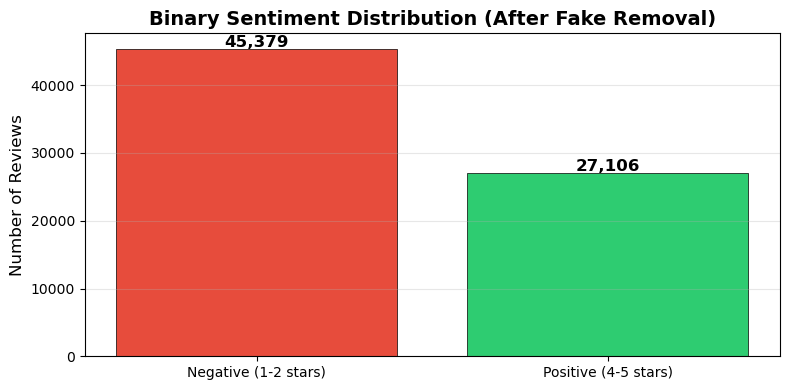

In [4]:
# Create binary sentiment labels
df = df_raw[df_raw['score'] != 3].copy()
df['sentiment'] = (df['score'] >= 4).astype(int)

excluded = len(df_raw) - len(df)
print(f'Excluded {excluded:,} neutral reviews (score = 3)')
print(f'Remaining: {len(df):,} reviews')
print(f'\nSentiment distribution:')
sentiment_counts = df['sentiment'].value_counts().sort_index()
for label, count in sentiment_counts.items():
    name = 'Negative' if label == 0 else 'Positive'
    print(f'  {name} ({label}): {count:,} ({count/len(df)*100:.1f}%)')

imbalance_ratio = sentiment_counts[0] / sentiment_counts[1]
print(f'\nImbalance ratio (Neg/Pos): {imbalance_ratio:.2f}:1')
print('Using class_weight="balanced" to handle this imbalance.')

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(['Negative (1-2 stars)', 'Positive (4-5 stars)'],
              [sentiment_counts[0], sentiment_counts[1]],
              color=colors, edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, [sentiment_counts[0], sentiment_counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Binary Sentiment Distribution (After Fake Removal)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Train/Test Split

Stratified 80/20 split to preserve class proportions in both sets.

In [5]:
X_text = df['content_clean'].values
y = df['sentiment'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Keep track of test indices for final output
df_reset = df.reset_index(drop=True)
train_idx, test_idx = train_test_split(
    df_reset.index, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f'Train set: {len(X_train_text):,} reviews')
print(f'Test set:  {len(X_test_text):,} reviews')
print(f'\nTrain class distribution:')
for label in [0, 1]:
    count = (y_train == label).sum()
    name = 'Negative' if label == 0 else 'Positive'
    print(f'  {name}: {count:,} ({count/len(y_train)*100:.1f}%)')
print(f'\nTest class distribution:')
for label in [0, 1]:
    count = (y_test == label).sum()
    name = 'Negative' if label == 0 else 'Positive'
    print(f'  {name}: {count:,} ({count/len(y_test)*100:.1f}%)')

Train set: 57,988 reviews
Test set:  14,497 reviews

Train class distribution:
  Negative: 36,303 (62.6%)
  Positive: 21,685 (37.4%)

Test class distribution:
  Negative: 9,076 (62.6%)
  Positive: 5,421 (37.4%)


## 4. TF-IDF Vectorization

Convert review text to TF-IDF features:
- **max_features=10,000** — good coverage while keeping training fast
- **ngram_range=(1,2)** — captures phrases like "not good", "very bad"
- **sublinear_tf=True** — applies log(1 + tf) dampening for better feature scaling
- **min_df=3, max_df=0.95** — removes rare typos and ultra-common stopwords

In [6]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'Train matrix: {X_train_tfidf.shape} (sparse, {X_train_tfidf.nnz:,} non-zero elements)')
print(f'Test matrix:  {X_test_tfidf.shape}')
print(f'Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%')

# Show some sample features
feature_names = tfidf.get_feature_names_out()
print(f'\nSample unigrams: {list(feature_names[:10])}')
bigrams = [f for f in feature_names if ' ' in f]
print(f'Sample bigrams:  {bigrams[:10]}')
print(f'Total bigrams:   {len(bigrams):,}')

Vocabulary size: 10,000
Train matrix: (57988, 10000) (sparse, 2,359,579 non-zero elements)
Test matrix:  (14497, 10000)
Sparsity: 99.59%

Sample unigrams: ['00', '000', '10', '10 10', '10 days', '10 minutes', '10 seconds', '10 times', '10 years', '100']
Sample bigrams:  ['10 10', '10 days', '10 minutes', '10 seconds', '10 times', '10 years', '14 99', '20 minutes', '24 hours', '30 day']
Total bigrams:   7,248


## 5. Model Training & Evaluation

Train 2 classifiers and evaluate each:
- **Logistic Regression** — L2-regularized, balanced class weights
- **Multinomial Naive Bayes** — Laplace smoothing (alpha=0.1)

In [7]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
    ),
    'Multinomial NB': MultinomialNB(alpha=0.1),
}

print(f'Defined {len(models)} models for comparison.')
for name, model in models.items():
    print(f'  - {name}: {model.__class__.__name__}')

Defined 2 models for comparison.
  - Logistic Regression: LogisticRegression
  - Multinomial NB: MultinomialNB


In [8]:
# Train all models and collect results
results = {}
predictions = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

for name, model in models.items():
    print(f'\n{"=" * 65}')
    print(f'Training: {name}')
    print(f'{"=" * 65}')
    
    # Train
    model.fit(X_train_tfidf, y_train)
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    predictions[name] = y_pred
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_neg = f1_score(y_test, y_pred, pos_label=0)
    f1_pos = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    results[name] = {
        'Accuracy': acc,
        'F1 (Weighted)': f1_w,
        'F1 (Negative)': f1_neg,
        'F1 (Positive)': f1_pos,
        'Precision': prec,
        'Recall': rec,
        'CV Mean F1': cv_mean,
        'CV Std': cv_std,
    }
    
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
    print(f'3-Fold CV F1 (weighted): {cv_mean:.4f} (+/- {cv_std:.4f})')

print(f'\n{"=" * 65}')
print('All models trained successfully.')


Training: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.94      0.94      9076
    Positive       0.90      0.89      0.90      5421

    accuracy                           0.92     14497
   macro avg       0.92      0.92      0.92     14497
weighted avg       0.92      0.92      0.92     14497

3-Fold CV F1 (weighted): 0.9207 (+/- 0.0014)

Training: Multinomial NB

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.98      0.93      9076
    Positive       0.95      0.78      0.86      5421

    accuracy                           0.90     14497
   macro avg       0.92      0.88      0.89     14497
weighted avg       0.91      0.90      0.90     14497

3-Fold CV F1 (weighted): 0.9063 (+/- 0.0021)

All models trained successfully.


## 5.1 Detailed Cross-Validation Analysis

Perform 5-fold stratified cross-validation on both models across multiple scoring metrics (Accuracy, F1, Precision, Recall) to assess generalization and stability.

In [9]:
# --- Detailed 5-Fold Cross-Validation for Both Models ---
from sklearn.model_selection import cross_validate

cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

scoring_metrics = {
    'accuracy': 'accuracy',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
}

# Fresh model instances for CV (training above already fitted them)
cv_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
    ),
    'Multinomial NB': MultinomialNB(alpha=0.1),
}

cv_results_all = {}

for name, model in cv_models.items():
    print(f'\n{"=" * 65}')
    print(f'5-Fold Cross-Validation: {name}')
    print(f'{"=" * 65}')
    
    cv_result = cross_validate(
        model, X_train_tfidf, y_train, cv=cv_5fold,
        scoring=scoring_metrics, return_train_score=True, n_jobs=-1
    )
    cv_results_all[name] = cv_result
    
    # Per-fold results table
    fold_df = pd.DataFrame({
        'Fold': [f'Fold {i+1}' for i in range(5)],
        'Train Accuracy': cv_result['train_accuracy'],
        'Test Accuracy': cv_result['test_accuracy'],
        'Train F1': cv_result['train_f1_weighted'],
        'Test F1': cv_result['test_f1_weighted'],
        'Test Precision': cv_result['test_precision_weighted'],
        'Test Recall': cv_result['test_recall_weighted'],
    })
    print(f'\nPer-Fold Results:')
    print(fold_df.round(4).to_string(index=False))
    
    # Summary statistics
    print(f'\nSummary (Test Set):')
    print(f'  Accuracy:  {cv_result["test_accuracy"].mean():.4f} +/- {cv_result["test_accuracy"].std():.4f}')
    print(f'  F1:        {cv_result["test_f1_weighted"].mean():.4f} +/- {cv_result["test_f1_weighted"].std():.4f}')
    print(f'  Precision: {cv_result["test_precision_weighted"].mean():.4f} +/- {cv_result["test_precision_weighted"].std():.4f}')
    print(f'  Recall:    {cv_result["test_recall_weighted"].mean():.4f} +/- {cv_result["test_recall_weighted"].std():.4f}')
    
    # Check for overfitting
    train_f1 = cv_result['train_f1_weighted'].mean()
    test_f1 = cv_result['test_f1_weighted'].mean()
    gap = train_f1 - test_f1
    print(f'\n  Train-Test F1 Gap: {gap:.4f} ({"Low — no overfitting" if gap < 0.02 else "Moderate gap — possible overfitting"})')

# --- Cross-Validation Comparison Table ---
print(f'\n{"=" * 65}')
print('Cross-Validation Comparison (5-Fold)')
print(f'{"=" * 65}')
comparison_data = {}
for name in cv_models.keys():
    cv_r = cv_results_all[name]
    comparison_data[name] = {
        'Accuracy (Mean)': cv_r['test_accuracy'].mean(),
        'Accuracy (Std)': cv_r['test_accuracy'].std(),
        'F1 Weighted (Mean)': cv_r['test_f1_weighted'].mean(),
        'F1 Weighted (Std)': cv_r['test_f1_weighted'].std(),
        'Precision (Mean)': cv_r['test_precision_weighted'].mean(),
        'Precision (Std)': cv_r['test_precision_weighted'].std(),
        'Recall (Mean)': cv_r['test_recall_weighted'].mean(),
        'Recall (Std)': cv_r['test_recall_weighted'].std(),
    }
cv_comparison_df = pd.DataFrame(comparison_data).T.round(4)
print(cv_comparison_df.to_string())


5-Fold Cross-Validation: Logistic Regression

Per-Fold Results:
  Fold  Train Accuracy  Test Accuracy  Train F1  Test F1  Test Precision  Test Recall
Fold 1          0.9392         0.9221    0.9391   0.9221          0.9220       0.9221
Fold 2          0.9391         0.9206    0.9391   0.9204          0.9204       0.9206
Fold 3          0.9396         0.9195    0.9395   0.9194          0.9194       0.9195
Fold 4          0.9387         0.9243    0.9386   0.9241          0.9241       0.9243
Fold 5          0.9401         0.9212    0.9401   0.9210          0.9209       0.9212

Summary (Test Set):
  Accuracy:  0.9215 +/- 0.0016
  F1:        0.9214 +/- 0.0016
  Precision: 0.9214 +/- 0.0016
  Recall:    0.9215 +/- 0.0016

  Train-Test F1 Gap: 0.0179 (Low — no overfitting)

5-Fold Cross-Validation: Multinomial NB

Per-Fold Results:
  Fold  Train Accuracy  Test Accuracy  Train F1  Test F1  Test Precision  Test Recall
Fold 1          0.9148         0.9104    0.9130   0.9084          0.9147    

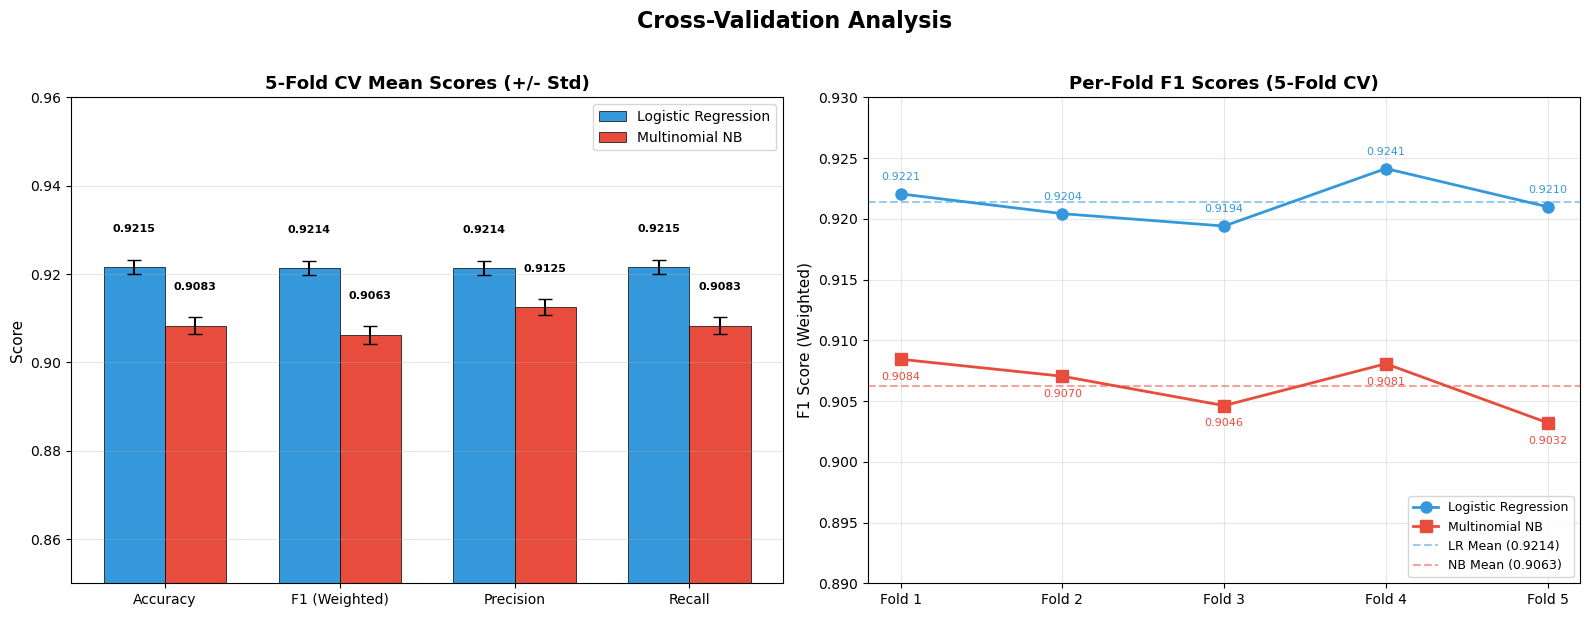

Saved: images/sentiment_cross_validation.png


In [10]:
# --- Cross-Validation Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Box plot of CV scores across folds for each metric
cv_metric_names = ['Accuracy', 'F1 (Weighted)', 'Precision', 'Recall']
cv_metric_keys = ['test_accuracy', 'test_f1_weighted', 'test_precision_weighted', 'test_recall_weighted']

box_data_lr = [cv_results_all['Logistic Regression'][k] for k in cv_metric_keys]
box_data_nb = [cv_results_all['Multinomial NB'][k] for k in cv_metric_keys]

x = np.arange(len(cv_metric_names))
width = 0.35

# Mean bars with error bars (std)
lr_means = [np.mean(d) for d in box_data_lr]
lr_stds = [np.std(d) for d in box_data_lr]
nb_means = [np.mean(d) for d in box_data_nb]
nb_stds = [np.std(d) for d in box_data_nb]

bars1 = axes[0].bar(x - width/2, lr_means, width, yerr=lr_stds, capsize=5,
                     label='Logistic Regression', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x + width/2, nb_means, width, yerr=nb_stds, capsize=5,
                     label='Multinomial NB', color='#e74c3c', edgecolor='black', linewidth=0.5)

for bar, val in zip(bars1, lr_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')
for bar, val in zip(bars2, nb_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('5-Fold CV Mean Scores (+/- Std)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cv_metric_names, fontsize=10)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0.85, 0.96)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Per-fold F1 scores line plot
folds = [f'Fold {i+1}' for i in range(5)]
lr_f1_folds = cv_results_all['Logistic Regression']['test_f1_weighted']
nb_f1_folds = cv_results_all['Multinomial NB']['test_f1_weighted']

axes[1].plot(folds, lr_f1_folds, 'o-', color='#3498db', lw=2, markersize=8, label='Logistic Regression')
axes[1].plot(folds, nb_f1_folds, 's-', color='#e74c3c', lw=2, markersize=8, label='Multinomial NB')

# Add mean lines
axes[1].axhline(y=lr_f1_folds.mean(), color='#3498db', linestyle='--', alpha=0.5, label=f'LR Mean ({lr_f1_folds.mean():.4f})')
axes[1].axhline(y=nb_f1_folds.mean(), color='#e74c3c', linestyle='--', alpha=0.5, label=f'NB Mean ({nb_f1_folds.mean():.4f})')

for i, (lr_val, nb_val) in enumerate(zip(lr_f1_folds, nb_f1_folds)):
    axes[1].annotate(f'{lr_val:.4f}', (folds[i], lr_val), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=8, color='#3498db')
    axes[1].annotate(f'{nb_val:.4f}', (folds[i], nb_val), textcoords='offset points',
                     xytext=(0, -15), ha='center', fontsize=8, color='#e74c3c')

axes[1].set_ylabel('F1 Score (Weighted)', fontsize=11)
axes[1].set_title('Per-Fold F1 Scores (5-Fold CV)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.89, 0.93)

plt.suptitle('Cross-Validation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: images/sentiment_cross_validation.png')

## 6. Confusion Matrices

Visualize prediction errors for each model. The diagonal shows correct predictions; off-diagonal shows misclassifications.

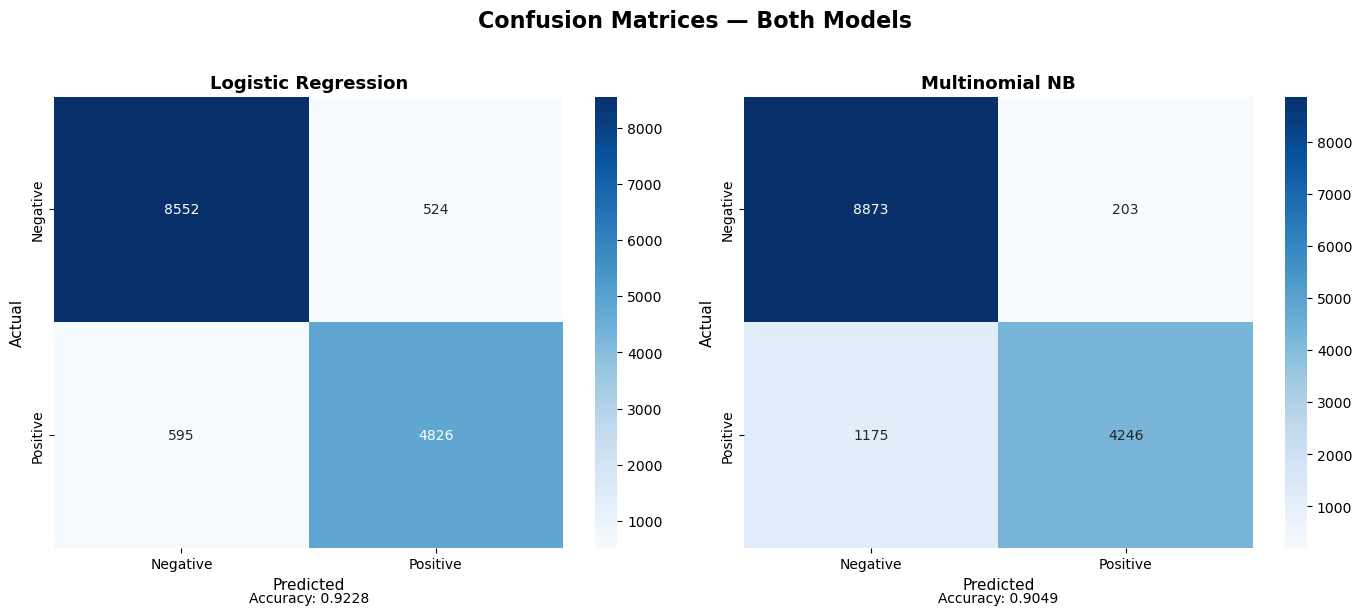

Saved: images/sentiment_confusion_matrices.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=11)
    
    # Add accuracy annotation
    acc = accuracy_score(y_test, y_pred)
    axes[idx].text(0.5, -0.12, f'Accuracy: {acc:.4f}',
                   transform=axes[idx].transAxes, ha='center', fontsize=10)

plt.suptitle('Confusion Matrices — Both Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: images/sentiment_confusion_matrices.png')

## 7. ROC Curves

Compare model discrimination ability via ROC curves and AUC scores. Higher AUC = better at separating positive from negative reviews.

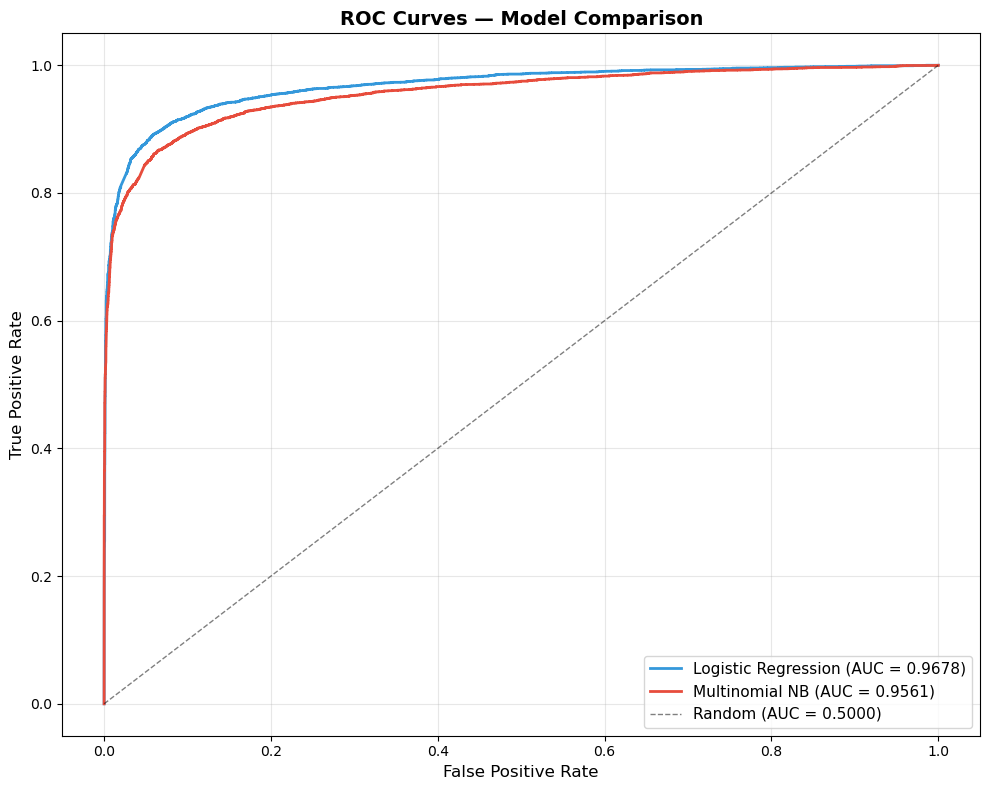

Saved: images/sentiment_roc_curves.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#3498db', '#e74c3c']

for idx, (name, model) in enumerate(models.items()):
    # Get probability scores
    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_scores = model.decision_function(X_test_tfidf)
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[idx], lw=2,
            label=f'{name} (AUC = {roc_auc:.4f})')
    results[name]['AUC'] = roc_auc

# Diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: images/sentiment_roc_curves.png')

## 8. Model Comparison

Side-by-side comparison of both models across key metrics.

Model Comparison Summary:
                     Accuracy  F1 (Weighted)  F1 (Negative)  F1 (Positive)  Precision  Recall  CV Mean F1  CV Std     AUC
Logistic Regression    0.9228         0.9227         0.9386         0.8961     0.9227  0.9228      0.9207  0.0014  0.9678
Multinomial NB         0.9049         0.9027         0.9279         0.8604     0.9097  0.9049      0.9063  0.0021  0.9561

Best model: Logistic Regression (F1 Weighted = 0.9227)


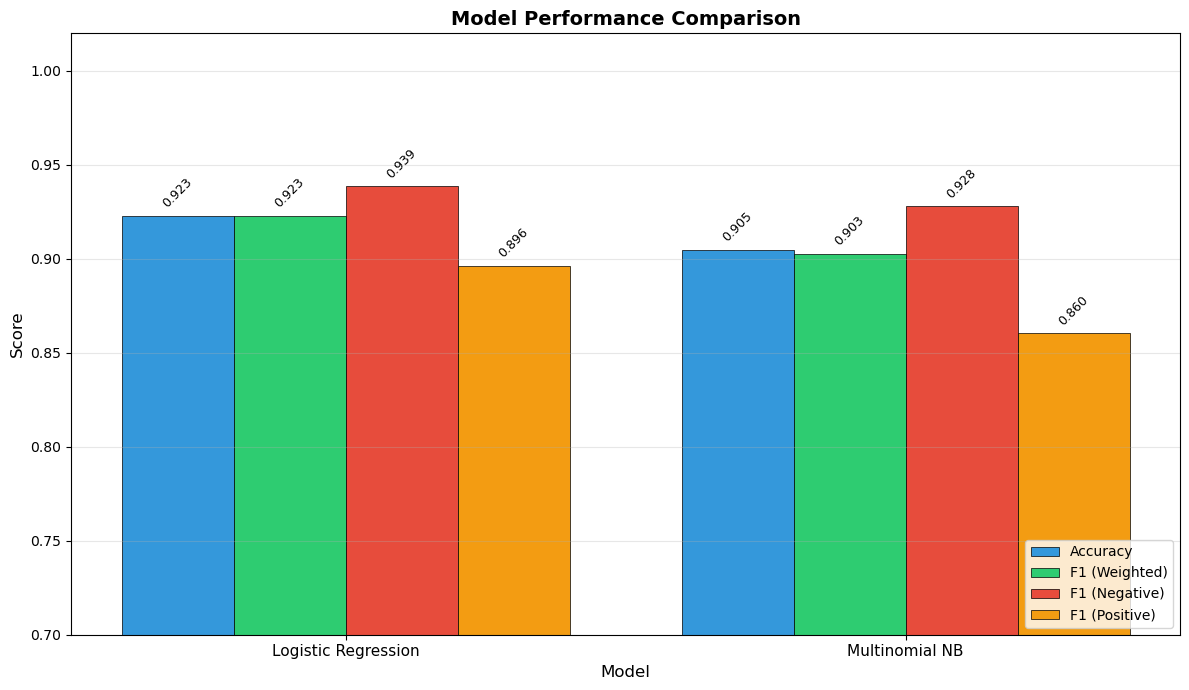

Saved: images/sentiment_model_comparison.png


In [13]:
# Summary table
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print('Model Comparison Summary:')
print('=' * 90)
print(results_df.to_string())

# Find best model
best_model_name = results_df['F1 (Weighted)'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1 (Weighted)']
print(f'\nBest model: {best_model_name} (F1 Weighted = {best_f1:.4f})')

# Grouped bar chart
metrics_to_plot = ['Accuracy', 'F1 (Weighted)', 'F1 (Negative)', 'F1 (Positive)']
x = np.arange(len(models))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 7))

bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, metric in enumerate(metrics_to_plot):
    values = [results[name][metric] for name in models.keys()]
    bars = ax.bar(x + i * width, values, width, label=metric, color=bar_colors[i],
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, rotation=45)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models.keys(), fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0.7, 1.02)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: images/sentiment_model_comparison.png')

## 9. Feature Importance — Top Words

Extract the most influential words for each sentiment class from Logistic Regression coefficients. Positive coefficients push toward Positive sentiment; negative coefficients push toward Negative.

Top 20 Positive Sentiment Words:
  love                      +11.6232
  great                     +10.2237
  easy                      +8.1705
  excellent                 +5.8978
  amazing                   +5.8595
  best                      +5.8588
  awesome                   +5.4613
  shopping                  +4.7150
  good                      +4.5654
  perfect                   +4.2017
  love the                  +4.1687
  sometimes                 +4.1502
  fast                      +4.1487
  quick                     +4.1357
  nice                      +4.0803
  always                    +3.9718
  thank                     +3.8539
  wonderful                 +3.8313
  easy to                   +3.7602
  convenient                +3.7157

Top 20 Negative Sentiment Words:
  terrible                  -6.3942
  horrible                  -6.3575
  not                       -6.2810
  worst                     -5.8673
  useless                   -4.8114
  slow                      -4.

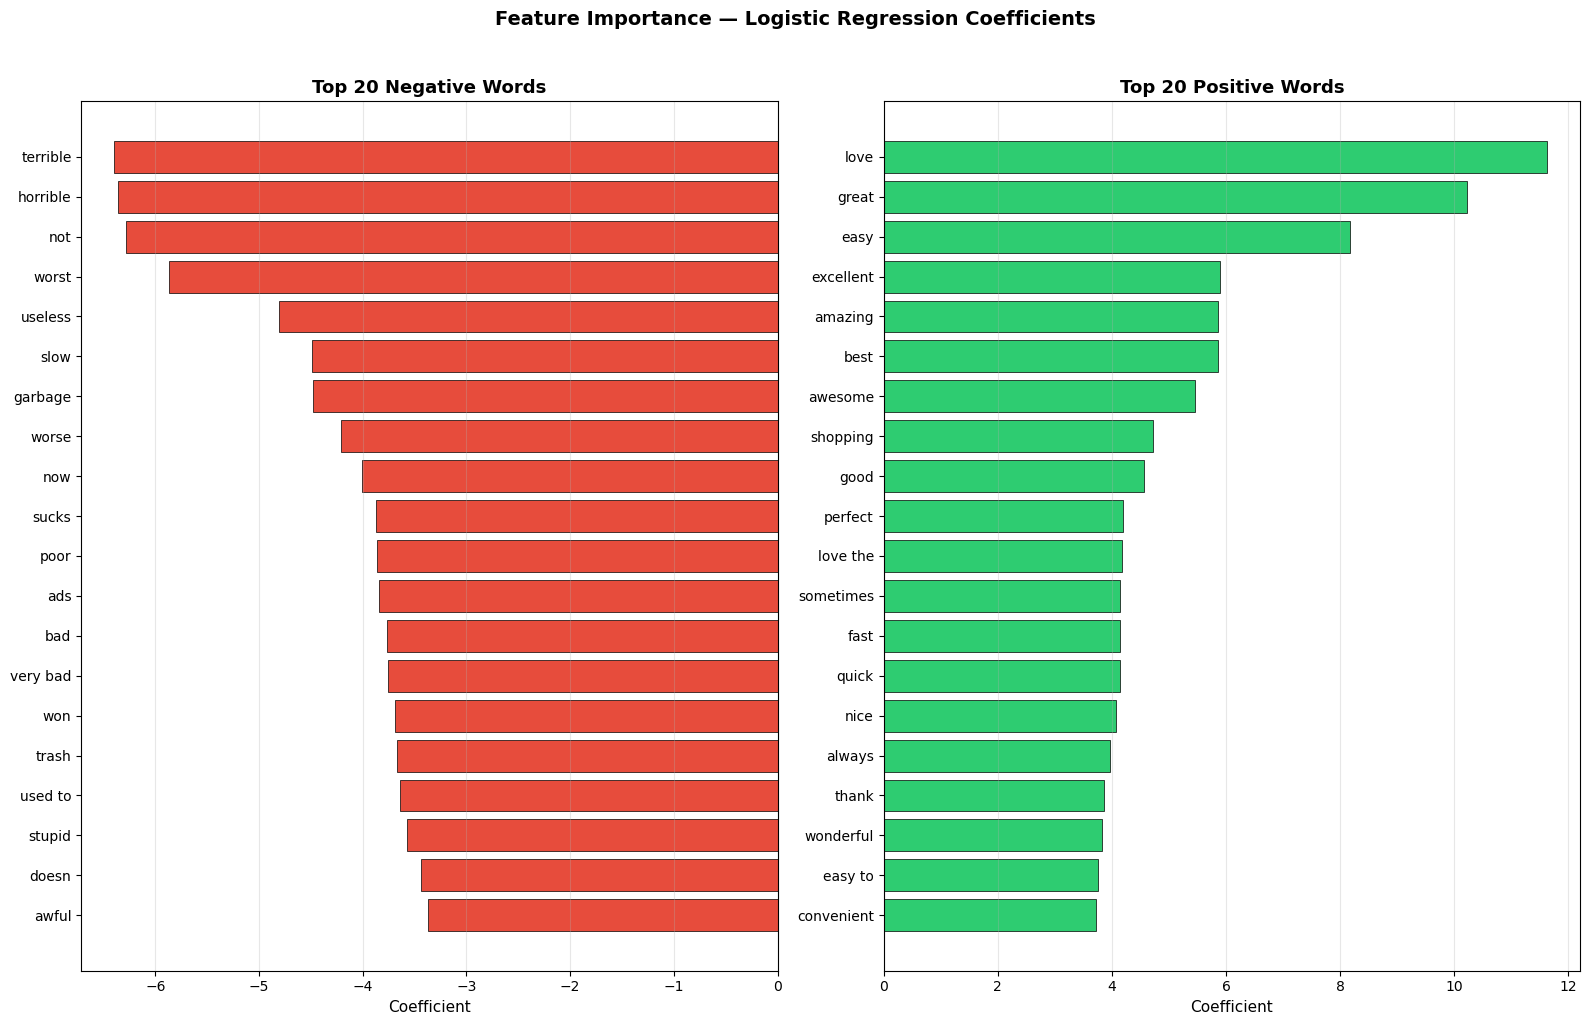

Saved: images/sentiment_top_words.png


In [14]:
# Use Logistic Regression coefficients for interpretability
lr_model = models['Logistic Regression']
feature_names = tfidf.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Top 20 positive and negative words
top_n = 20
top_positive_idx = np.argsort(coefficients)[-top_n:][::-1]
top_negative_idx = np.argsort(coefficients)[:top_n]

top_positive_words = [(feature_names[i], coefficients[i]) for i in top_positive_idx]
top_negative_words = [(feature_names[i], coefficients[i]) for i in top_negative_idx]

print('Top 20 Positive Sentiment Words:')
for word, coef in top_positive_words:
    print(f'  {word:25s} {coef:+.4f}')

print(f'\nTop 20 Negative Sentiment Words:')
for word, coef in top_negative_words:
    print(f'  {word:25s} {coef:+.4f}')

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# Negative words (left)
neg_words = [w for w, _ in reversed(top_negative_words)]
neg_coefs = [c for _, c in reversed(top_negative_words)]
ax1.barh(neg_words, neg_coefs, color='#e74c3c', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Coefficient', fontsize=11)
ax1.set_title('Top 20 Negative Words', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Positive words (right)
pos_words = [w for w, _ in reversed(top_positive_words)]
pos_coefs = [c for _, c in reversed(top_positive_words)]
ax2.barh(pos_words, pos_coefs, color='#2ecc71', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Coefficient', fontsize=11)
ax2.set_title('Top 20 Positive Words', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — Logistic Regression Coefficients', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_top_words.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: images/sentiment_top_words.png')

## 10. Word Clouds

Visual representation of the most frequent words in positive and negative reviews.

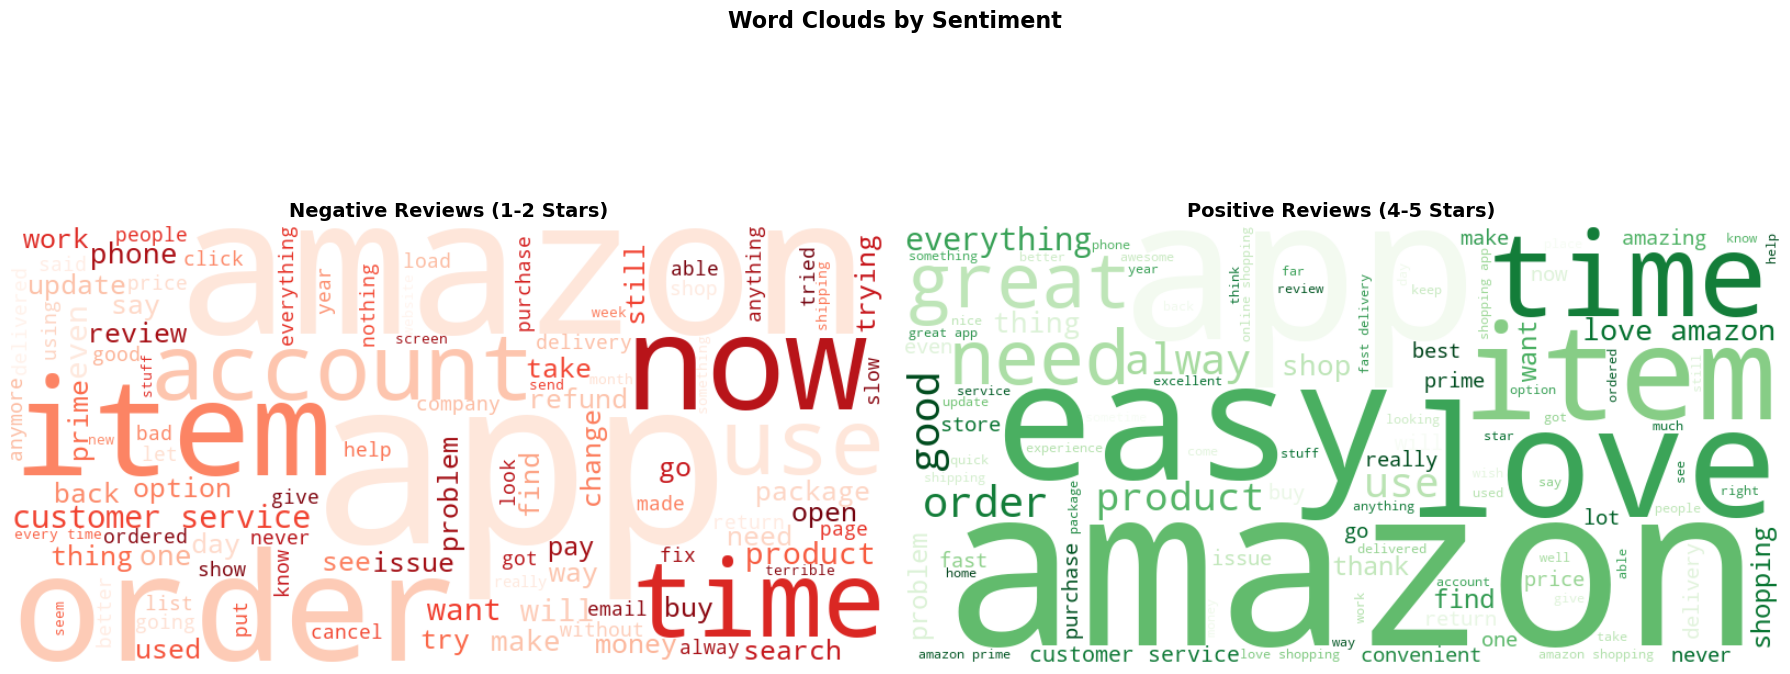

Saved: images/sentiment_wordclouds.png


In [15]:
# Combine text for each sentiment class
positive_text = ' '.join(df[df['sentiment'] == 1]['content_clean'].values)
negative_text = ' '.join(df[df['sentiment'] == 0]['content_clean'].values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Negative word cloud
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100, random_state=RANDOM_SEED)
wc_neg.generate(negative_text)
ax1.imshow(wc_neg, interpolation='bilinear')
ax1.set_title('Negative Reviews (1-2 Stars)', fontsize=14, fontweight='bold')
ax1.axis('off')

# Positive word cloud
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100, random_state=RANDOM_SEED)
wc_pos.generate(positive_text)
ax2.imshow(wc_pos, interpolation='bilinear')
ax2.set_title('Positive Reviews (4-5 Stars)', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: images/sentiment_wordclouds.png')

## 11. Sentiment Distribution Analysis

Compare VADER compound scores (rule-based, from Phase 1) with ML model predictions to see how they align.

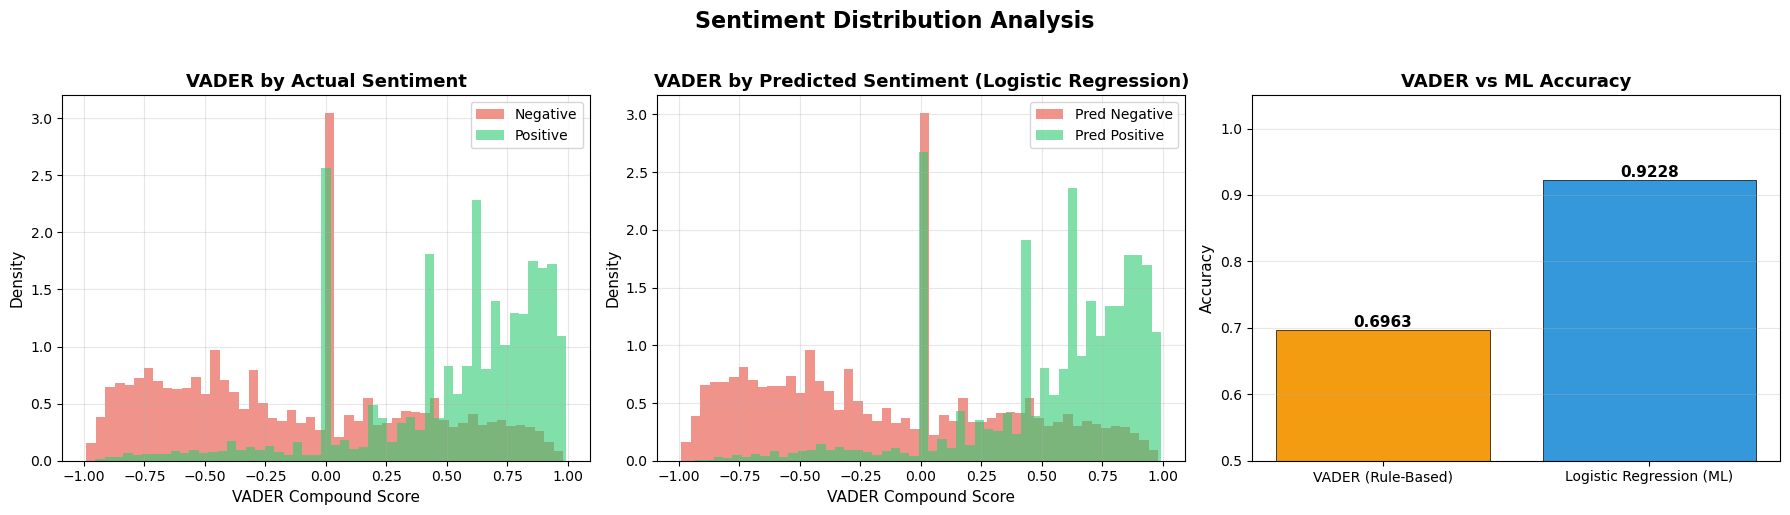

VADER accuracy:              0.6963
Logistic Regression accuracy: 0.9228
VADER-ML agreement rate:     0.7012

Saved: images/sentiment_vader_vs_model.png


In [16]:
# Use the best model's predictions on the test set
best_pred = predictions[best_model_name]

# Get VADER scores for test set
df_test = df_reset.iloc[test_idx].copy()
df_test['predicted'] = best_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. VADER distribution by actual sentiment
for label, color, name in [(0, '#e74c3c', 'Negative'), (1, '#2ecc71', 'Positive')]:
    subset = df_test[df_test['sentiment'] == label]['vader_compound']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xlabel('VADER Compound Score', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('VADER by Actual Sentiment', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. VADER distribution by predicted sentiment
for label, color, name in [(0, '#e74c3c', 'Pred Negative'), (1, '#2ecc71', 'Pred Positive')]:
    subset = df_test[df_test['predicted'] == label]['vader_compound']
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
axes[1].set_xlabel('VADER Compound Score', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title(f'VADER by Predicted Sentiment ({best_model_name})', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. VADER vs ML agreement
df_test['vader_sentiment'] = (df_test['vader_compound'] >= 0).astype(int)
agreement = (df_test['vader_sentiment'] == df_test['predicted']).mean()
vader_acc = accuracy_score(df_test['sentiment'], df_test['vader_sentiment'])
ml_acc = accuracy_score(df_test['sentiment'], df_test['predicted'])

methods = ['VADER (Rule-Based)', f'{best_model_name} (ML)']
accs = [vader_acc, ml_acc]
bar_colors = ['#f39c12', '#3498db']
bars = axes[2].bar(methods, accs, color=bar_colors, edgecolor='black', linewidth=0.5)
for bar, acc_val in zip(bars, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc_val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Accuracy', fontsize=11)
axes[2].set_title('VADER vs ML Accuracy', fontsize=13, fontweight='bold')
axes[2].set_ylim(0.5, 1.05)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Sentiment Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_vader_vs_model.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'VADER accuracy:              {vader_acc:.4f}')
print(f'{best_model_name} accuracy: {ml_acc:.4f}')
print(f'VADER-ML agreement rate:     {agreement:.4f}')
print('\nSaved: images/sentiment_vader_vs_model.png')

## 12. Impact Analysis — Fake Review Removal

Quantify the value of Phase 2 (fake detection) by training the same model on:
1. **Filtered data** (clean, 79K reviews) — fake reviews removed
2. **Unfiltered data** (full, 82K reviews) — fake reviews included

If fake removal improves model quality, the filtered model should have higher F1/accuracy.

Unfiltered dataset: 82,062 reviews
After excluding neutrals: 75,354 reviews

Training Logistic Regression on unfiltered data...

Impact Analysis: Logistic Regression
               Filtered (Clean)  Unfiltered (With Fakes)   Delta  Delta (%)
Accuracy                 0.9228                   0.9263 -0.0035      -0.38
F1 (Weighted)            0.9227                   0.9263 -0.0036      -0.39
F1 (Negative)            0.9386                   0.9396 -0.0010      -0.11
F1 (Positive)            0.8961                   0.9054 -0.0093      -1.03
Precision                0.9227                   0.9262 -0.0035      -0.38
Recall                   0.9228                   0.9263 -0.0035      -0.38


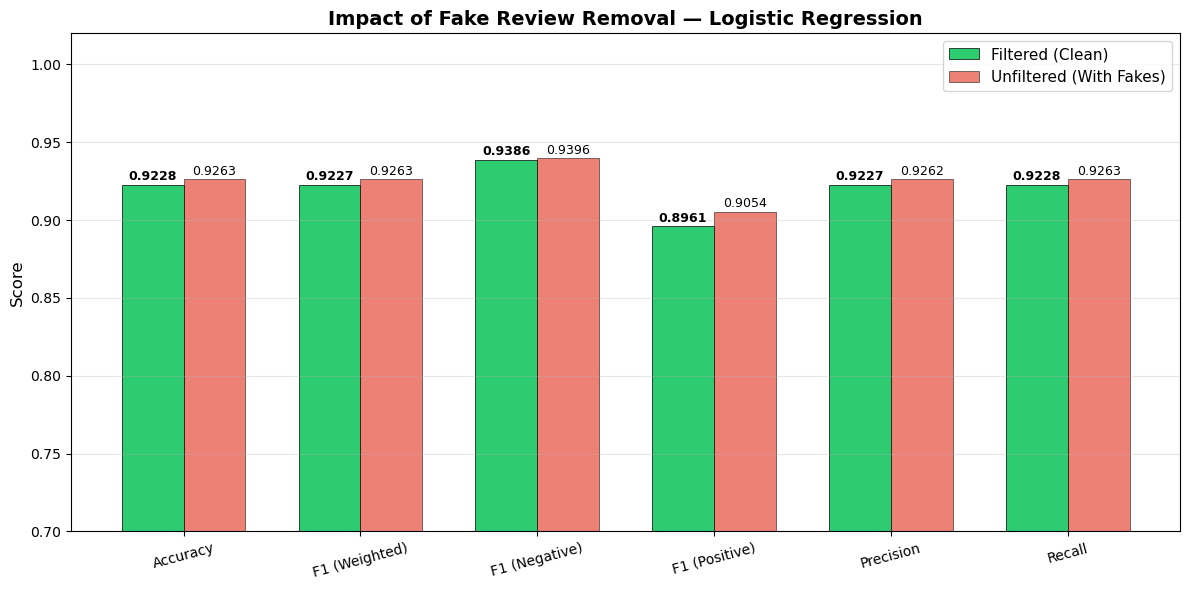

Saved: images/sentiment_impact_analysis.png


In [17]:
# Load unfiltered dataset
df_unfiltered = pd.read_csv(f'{SAVE_DIR}reviews_with_fake_detection.csv')
df_unfiltered = df_unfiltered.dropna(subset=['content_clean'])
print(f'Unfiltered dataset: {len(df_unfiltered):,} reviews')

# Apply same labeling
df_unf = df_unfiltered[df_unfiltered['score'] != 3].copy()
df_unf['sentiment'] = (df_unf['score'] >= 4).astype(int)
print(f'After excluding neutrals: {len(df_unf):,} reviews')

# Same split ratio
X_unf_text = df_unf['content_clean'].values
y_unf = df_unf['sentiment'].values
X_train_unf, X_test_unf, y_train_unf, y_test_unf = train_test_split(
    X_unf_text, y_unf, test_size=0.2, random_state=RANDOM_SEED, stratify=y_unf
)

# Same TF-IDF
tfidf_unf = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2), min_df=3, max_df=0.95, sublinear_tf=True
)
X_train_unf_tfidf = tfidf_unf.fit_transform(X_train_unf)
X_test_unf_tfidf = tfidf_unf.transform(X_test_unf)

# Train same best model on unfiltered data
print(f'\nTraining {best_model_name} on unfiltered data...')
if best_model_name == 'Logistic Regression':
    model_unf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)
else:
    model_unf = MultinomialNB(alpha=0.1)

model_unf.fit(X_train_unf_tfidf, y_train_unf)
y_pred_unf = model_unf.predict(X_test_unf_tfidf)

# Compute metrics for both
metrics_filtered = {
    'Accuracy': accuracy_score(y_test, predictions[best_model_name]),
    'F1 (Weighted)': f1_score(y_test, predictions[best_model_name], average='weighted'),
    'F1 (Negative)': f1_score(y_test, predictions[best_model_name], pos_label=0),
    'F1 (Positive)': f1_score(y_test, predictions[best_model_name], pos_label=1),
    'Precision': precision_score(y_test, predictions[best_model_name], average='weighted'),
    'Recall': recall_score(y_test, predictions[best_model_name], average='weighted'),
}

metrics_unfiltered = {
    'Accuracy': accuracy_score(y_test_unf, y_pred_unf),
    'F1 (Weighted)': f1_score(y_test_unf, y_pred_unf, average='weighted'),
    'F1 (Negative)': f1_score(y_test_unf, y_pred_unf, pos_label=0),
    'F1 (Positive)': f1_score(y_test_unf, y_pred_unf, pos_label=1),
    'Precision': precision_score(y_test_unf, y_pred_unf, average='weighted'),
    'Recall': recall_score(y_test_unf, y_pred_unf, average='weighted'),
}

# Impact comparison table
impact_df = pd.DataFrame({
    'Filtered (Clean)': metrics_filtered,
    'Unfiltered (With Fakes)': metrics_unfiltered,
}).round(4)
impact_df['Delta'] = (impact_df['Filtered (Clean)'] - impact_df['Unfiltered (With Fakes)']).round(4)
impact_df['Delta (%)'] = ((impact_df['Delta'] / impact_df['Unfiltered (With Fakes)']) * 100).round(2)

print(f'\nImpact Analysis: {best_model_name}')
print('=' * 75)
print(impact_df.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
metrics_list = list(metrics_filtered.keys())
x = np.arange(len(metrics_list))
width = 0.35

filtered_vals = [metrics_filtered[m] for m in metrics_list]
unfiltered_vals = [metrics_unfiltered[m] for m in metrics_list]

bars1 = ax.bar(x - width/2, filtered_vals, width, label='Filtered (Clean)',
               color='#2ecc71', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, unfiltered_vals, width, label='Unfiltered (With Fakes)',
               color='#e74c3c', edgecolor='black', linewidth=0.5, alpha=0.7)

for bar, val in zip(bars1, filtered_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, unfiltered_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Impact of Fake Review Removal — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=10, rotation=15)
ax.legend(fontsize=11)
ax.set_ylim(0.7, 1.02)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}sentiment_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: images/sentiment_impact_analysis.png')

## 13. Save Results

In [19]:
# --- Save Predictions ---
best_model = models[best_model_name]
df_output = df_reset.iloc[test_idx][['reviewId', 'content', 'score', 'sentiment', 'vader_compound']].copy()
df_output['predicted_sentiment'] = predictions[best_model_name]

# Add predicted probability if available
if hasattr(best_model, 'predict_proba'):
    df_output['predicted_proba_positive'] = best_model.predict_proba(X_test_tfidf)[:, 1]
elif hasattr(best_model, 'decision_function'):
    df_output['decision_score'] = best_model.decision_function(X_test_tfidf)

df_output['predicted_label'] = df_output['predicted_sentiment'].map({0: 'Negative', 1: 'Positive'})
df_output['actual_label'] = df_output['sentiment'].map({0: 'Negative', 1: 'Positive'})

df_output.to_csv(f'{SAVE_DIR}sentiment_predictions.csv', index=False, encoding='utf-8-sig')
print(f'Saved: sentiment_predictions.csv ({len(df_output):,} rows, {df_output.shape[1]} cols)')

# Save model comparison results
results_df.to_csv(f'{SAVE_DIR}sentiment_model_results.csv', encoding='utf-8-sig')
print(f'Saved: sentiment_model_results.csv')

print(f'\nPredictions sample:')
df_output.head(5)

Saved: sentiment_predictions.csv (14,497 rows, 9 cols)
Saved: sentiment_model_results.csv

Predictions sample:


,reviewId,content,score,sentiment,vader_compound,predicted_sentiment,predicted_proba_positive,predicted_label,actual_label
22570,a0e1aa0d-fc50-4a2d-98aa-8f3bd486a8d3,I love this app & service but i really wish th...,4,1,0.9856,1,0.767653,Positive,Positive
54347,94d2e262-bfff-4e14-b41b-705212d26f63,Try and go to get a little bit of a few things...,5,1,0.0000,1,0.727177,Positive,Positive
64103,c4b1717e-0e96-4404-b18e-8e7d54494406,Great quality products. Delivery is always on ...,5,1,0.6249,1,0.991036,Positive,Positive
45362,c402410e-cddb-43a5-83f0-fbbe06720e50,Great service so far,5,1,0.6249,1,0.996082,Positive,Positive
69814,4435389e-49ef-4bd5-9025-1b02022b8871,Consistently unable to deliver to the correct ...,1,0,-0.5719,0,0.034295,Negative,Negative


In [20]:
# --- Final Summary ---
print(f'{"=" * 70}')
print(f'SENTIMENT ANALYSIS SUMMARY (Phase 3)')
print(f'{"=" * 70}')
print(f'\nInput: reviews_clean_for_sentiment.csv ({len(df_raw):,} reviews)')
print(f'After filtering neutrals: {len(df):,} reviews')
print(f'  Negative (1-2 stars): {(df["sentiment"]==0).sum():,}')
print(f'  Positive (4-5 stars): {(df["sentiment"]==1).sum():,}')
print(f'\nTF-IDF: {len(tfidf.vocabulary_):,} features (unigrams + bigrams)')
print(f'Train/Test split: {len(X_train_text):,} / {len(X_test_text):,} (80/20 stratified)')
print(f'\nModel Results:')
print(f'{"-" * 70}')
for name in models.keys():
    r = results[name]
    auc_str = f', AUC={r["AUC"]:.4f}' if 'AUC' in r else ''
    print(f'  {name:25s} Acc={r["Accuracy"]:.4f}, F1={r["F1 (Weighted)"]:.4f}, '
          f'CV={r["CV Mean F1"]:.4f}+/-{r["CV Std"]:.4f}{auc_str}')
print(f'\nBest Model: {best_model_name} (F1 Weighted = {best_f1:.4f})')
print(f'\n5-Fold Cross-Validation (Detailed):')
print(cv_comparison_df.to_string())
print(f'\nImpact of Fake Review Removal:')
print(f'  F1 improvement: {impact_df.loc["F1 (Weighted)", "Delta"]:+.4f} ({impact_df.loc["F1 (Weighted)", "Delta (%)"]:+.2f}%)')
print(f'  Accuracy improvement: {impact_df.loc["Accuracy", "Delta"]:+.4f} ({impact_df.loc["Accuracy", "Delta (%)"]:+.2f}%)')
print(f'\nOutput Files:')
print(f'  sentiment_predictions.csv      ({len(df_output):,} rows)')
print(f'  sentiment_model_results.csv    ({len(results_df)} models)')
print(f'\nSaved Visualizations:')
for img in ['sentiment_distribution', 'sentiment_cross_validation', 'sentiment_confusion_matrices',
            'sentiment_roc_curves', 'sentiment_model_comparison', 'sentiment_top_words',
            'sentiment_wordclouds', 'sentiment_vader_vs_model', 'sentiment_impact_analysis']:
    print(f'  images/{img}.png')
print(f'\n{"=" * 70}')
print('Phase 3 complete. Sentiment analysis pipeline finished successfully.')
print(f'{"=" * 70}')

SENTIMENT ANALYSIS SUMMARY (Phase 3)

Input: reviews_clean_for_sentiment.csv (79,191 reviews)
After filtering neutrals: 72,485 reviews
  Negative (1-2 stars): 45,379
  Positive (4-5 stars): 27,106

TF-IDF: 10,000 features (unigrams + bigrams)
Train/Test split: 57,988 / 14,497 (80/20 stratified)

Model Results:
----------------------------------------------------------------------
  Logistic Regression       Acc=0.9228, F1=0.9227, CV=0.9207+/-0.0014, AUC=0.9678
  Multinomial NB            Acc=0.9049, F1=0.9027, CV=0.9063+/-0.0021, AUC=0.9561

Best Model: Logistic Regression (F1 Weighted = 0.9227)

5-Fold Cross-Validation (Detailed):
                     Accuracy (Mean)  Accuracy (Std)  F1 Weighted (Mean)  F1 Weighted (Std)  Precision (Mean)  Precision (Std)  Recall (Mean)  Recall (Std)
Logistic Regression           0.9215          0.0016              0.9214             0.0016            0.9214           0.0016         0.9215        0.0016
Multinomial NB                0.9083          0.